In [45]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [46]:
base = "/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets"

train_dir = base + "/Training"
test_dir = base + "/Testing"

print("Train exists:", tf.io.gfile.exists(train_dir))
print("Test exists:", tf.io.gfile.exists(test_dir))

Train exists: True
Test exists: True


In [47]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [48]:
print(len(train_data), len(val_data))

140 35


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

TensorFlow version: 2.19.0


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

TensorFlow version: 2.19.0


In [ ]:
import os
print(os.listdir("/kaggle/input"))

In [ ]:
data_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

In [ ]:
import os

base_path = "/kaggle/input"

dataset_name = os.listdir(base_path)[0]
dataset_path = os.path.join(base_path, dataset_name)

subfolders = os.listdir(dataset_path)

if "Training" in subfolders:
    data_dir = os.path.join(dataset_path, "Training")
    test_dir = os.path.join(dataset_path, "Testing")
elif "train" in subfolders:
    data_dir = os.path.join(dataset_path, "train")
    test_dir = os.path.join(dataset_path, "test")
else:
    data_dir = dataset_path
    test_dir = dataset_path

print("Training Path:", data_dir)
print("Testing Path:", test_dir)

In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
print(os.listdir("/kaggle/input/brain-tumor-mri-dataset"))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/brain-tumor-mri-dataset'

In [4]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

base_path = "/kaggle/input"

dataset_name = os.listdir(base_path)[0]
dataset_path = os.path.join(base_path, dataset_name)

print("Detected dataset folder:", dataset_path)
print(os.listdir(dataset_path))

Detected dataset folder: /kaggle/input/datasets
['ganeshkankalapathi']


In [6]:
import os

base_path = "/kaggle/input/datasets/ganeshkankalapathi"
print(os.listdir(base_path))

['brain-tumor-mri-datasets']


In [15]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(dirs)
    print("------")

/kaggle/input
['datasets']
------
/kaggle/input/datasets
['ganeshkankalapathi']
------
/kaggle/input/datasets/ganeshkankalapathi
['brain-tumor-mri-datasets']
------
/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets
[]
------


ROOT: /kaggle/input/datasets/ganeshkankalapathi
DIRS: ['brain-tumor-mri-datasets']
FILES SAMPLE: []
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets
DIRS: []
FILES SAMPLE: ['brain-tumor-mri-dataset']
------


In [18]:
data_dir = "/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets/brain-tumor-mri-dataset"
test_dir = data_dir

In [28]:
import zipfile
import os

zip_path = "/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets/brain-tumor-mri-dataset"
extract_path = "/kaggle/working/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print(os.listdir(extract_path))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets/brain-tumor-mri-dataset'

In [32]:
import os

for root, dirs, files in os.walk("/kaggle/working/dataset"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES SAMPLE:", files[:3])
    print("------")

In [33]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [34]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(dirs)
    print(files[:5])
    print("------")

/kaggle/input
['datasets']
[]
------
/kaggle/input/datasets
['ganeshkankalapathi']
[]
------
/kaggle/input/datasets/ganeshkankalapathi
['brain-mri-datasets']
[]
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets
['Training', 'Testing']
[]
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training
['pituitary', 'notumor', 'meningioma', 'glioma']
[]
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/pituitary
[]
['Tr-pi_124.jpg', 'Tr-pi_949.jpg', 'Tr-pi_786.jpg', 'Tr-pi_371.jpg', 'Tr-pi_599.jpg']
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/notumor
[]
['Tr-no_323.jpg', 'Tr-no_86.jpg', 'Tr-no_737.jpg', 'Tr-no_452.jpg', 'Tr-no_557.jpg']
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/meningioma
[]
['Tr-me_166.jpg', 'Tr-me_1256.jpg', 'Tr-me_115.jpg', 'Tr-me_431.jpg', 'Tr-me_971.jpg']
------
/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/glioma
[]
[

In [35]:
import os

print(os.listdir("/kaggle/input/datasets"))

['ganeshkankalapathi']


In [36]:
print(os.listdir("/kaggle/input/datasets/ganeshkankalapathi"))

['brain-mri-datasets']


In [37]:
print(os.listdir("/kaggle/input/datasets"))

['ganeshkankalapathi']


In [38]:
import os

base = "/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets"
print(os.listdir(base))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/ganeshkankalapathi/brain-tumor-mri-datasets'

In [39]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("------")

ROOT: /kaggle/input
DIRS: ['datasets']
FILES: []
------
ROOT: /kaggle/input/datasets
DIRS: ['ganeshkankalapathi']
FILES: []
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi
DIRS: ['brain-mri-datasets']
FILES: []
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets
DIRS: ['Training', 'Testing']
FILES: []
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training
DIRS: ['pituitary', 'notumor', 'meningioma', 'glioma']
FILES: []
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/pituitary
DIRS: []
FILES: ['Tr-pi_124.jpg', 'Tr-pi_949.jpg', 'Tr-pi_786.jpg', 'Tr-pi_371.jpg', 'Tr-pi_599.jpg']
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/notumor
DIRS: []
FILES: ['Tr-no_323.jpg', 'Tr-no_86.jpg', 'Tr-no_737.jpg', 'Tr-no_452.jpg', 'Tr-no_557.jpg']
------
ROOT: /kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets/Training/meningioma
DIRS: []
FILES: ['Tr-me_166.jpg', 'Tr-m

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

base_path = "/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets"
train_dir = base_path + "/Training"
test_dir = base_path + "/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

cnn = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, 3, activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

cnn.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early = EarlyStopping(patience=5, restore_best_weights=True)

history_cnn = cnn.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early])

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(len(class_names), activation='softmax')(x)

vgg = Model(base_model.input, out)

vgg.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = vgg.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early])

cnn_acc = cnn.evaluate(val_data)[1]
vgg_acc = vgg.evaluate(val_data)[1]

print("CNN Accuracy:", cnn_acc)
print("VGG Accuracy:", vgg_acc)

y_pred = vgg.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

plt.figure()
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.figure()
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title("VGG Accuracy")
plt.legend(['Train','Val'])
plt.show()

def gradcam(model, img_array, layer_name):
    grad_model = Model(model.inputs, [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap.numpy()

img_path = test_dir + "/glioma/" + os.listdir(test_dir + "/glioma")[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

heatmap = gradcam(vgg, img_array, "block5_conv3")

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img

plt.imshow(overlay.astype("uint8"))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure()

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(fpr, tpr, label=class_names[i])

plt.legend()
plt.title("ROC Curve")
plt.show()

cnn.save("cnn_model.h5")
vgg.save("vgg_model.h5")

2026-06-06 16:35:36.274447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780763736.457096      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780763736.507303      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780763736.946128      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763736.946163      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763736.946166      58 computation_placer.cc:177] computation placer alr

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780763750.209299      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780763750.215562      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1780763753.621406     134 service.cc:152] XLA service 0x788a14006840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780763753.621446     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780763753.621452     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780763754.040700     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 16:35:56.509413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 16:35:56.657279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/140 ━━━━━━━━━━━━━━━━━━━━ 17:55 8s/step - accuracy: 0.2500 - loss: 1.3949

I0000 00:00:1780763759.617931     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 201ms/step - accuracy: 0.6004 - loss: 0.9367 - val_accuracy: 0.7214 - val_loss: 0.6996
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.7556 - loss: 0.6281 - val_accuracy: 0.7937 - val_loss: 0.5312
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.8112 - loss: 0.5082 - val_accuracy: 0.8018 - val_loss: 0.4965
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.8449 - loss: 0.4299 - val_accuracy: 0.8384 - val_loss: 0.4036
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.8656 - loss: 0.3816 - val_accuracy: 0.8420 - val_loss: 0.4229
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.8766 - loss: 0.3388 - val_accuracy: 0.8580 - val_loss: 0.3743
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.8900 - loss: 0.2995 - val_accuracy: 0.8598 - val_loss: 0.3562
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.8996 - loss: 0.2733 - val_accur

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5: None -- [Errno -3] Temporary failure in name resolution

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 503ms/step - accuracy: 0.3915 - loss: 1.2305 - val_accuracy: 0.4830 - val_loss: 1.1412
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 489ms/step - accuracy: 0.5786 - loss: 0.9846 - val_accuracy: 0.6187 - val_loss: 0.9132
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 487ms/step - accuracy: 0.6212 - loss: 0.9267 - val_accuracy: 0.6866 - val_loss: 0.8216
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 489ms/step - accuracy: 0.6536 - loss: 0.8534 - val_accuracy: 0.6893 - val_loss: 0.7914
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 488ms/step - accuracy: 0.6589 - loss: 0.8350 - val_accuracy: 0.6973 - val_loss: 0.7684
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 486ms/step - accuracy: 0.6683 - loss: 0.8096 - val_accuracy: 0.6920 - val_loss: 0.7333
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 489ms/step - accuracy: 0.6967 - loss: 0.7701 - val_accuracy: 0.7366 - val_loss: 0.6927
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 69s 496ms/step - accuracy: 0.7045 - loss: 0

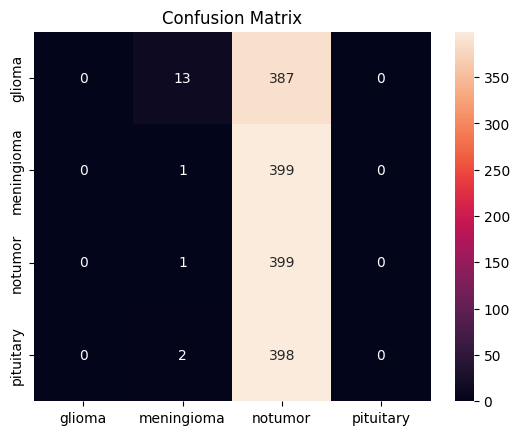

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.06      0.00      0.00       400
     notumor       0.25      1.00      0.40       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.25      1600
   macro avg       0.08      0.25      0.10      1600
weighted avg       0.08      0.25      0.10      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


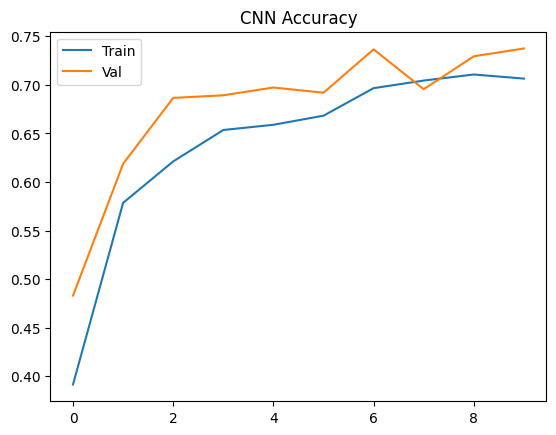

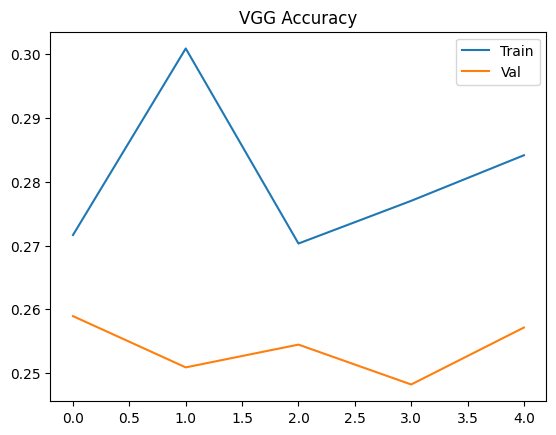

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_178']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

base_path = "/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets"
train_dir = base_path + "/Training"
test_dir = base_path + "/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

cnn = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, 3, activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

cnn.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

early = EarlyStopping(patience=5, restore_best_weights=True)

history_cnn = cnn.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early])

base_model = VGG16(weights=None, include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(len(class_names), activation='softmax')(x)

vgg = Model(base_model.input, out)

vgg.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = vgg.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early])

cnn_acc = cnn.evaluate(val_data)[1]
vgg_acc = vgg.evaluate(val_data)[1]

print("CNN Accuracy:", cnn_acc)
print("VGG Accuracy:", vgg_acc)

y_pred = vgg.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

plt.figure()
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.legend(['Train','Val'])
plt.show()

plt.figure()
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title("VGG Accuracy")
plt.legend(['Train','Val'])
plt.show()

def gradcam(model, img_array, layer_name):
    grad_model = Model(model.inputs, [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap.numpy()

img_path = test_dir + "/glioma/" + os.listdir(test_dir + "/glioma")[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

heatmap = gradcam(vgg, img_array, "block5_conv3")

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img

plt.imshow(overlay.astype("uint8"))
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure()

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(fpr, tpr, label=class_names[i])

plt.legend()
plt.title("ROC Curve")
plt.show()

cnn.save("cnn_model.h5")
vgg.save("vgg_model.h5")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [15]:
base_path = "/kaggle/input/datasets/ganeshkankalapathi/brain-mri-datasets"

train_dir = base_path + "/Training"
test_dir = base_path + "/Testing"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Test exists: True


In [16]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print(class_names)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [21]:
history_cnn = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 465ms/step - accuracy: 0.6540 - loss: 0.8479 - val_accuracy: 0.6848 - val_loss: 0.7432
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 443ms/step - accuracy: 0.7022 - loss: 0.7567 - val_accuracy: 0.7402 - val_loss: 0.6776
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 445ms/step - accuracy: 0.7201 - loss: 0.7093 - val_accuracy: 0.7482 - val_loss: 0.6335
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 446ms/step - accuracy: 0.7431 - loss: 0.6702 - val_accuracy: 0.7348 - val_loss: 0.6306
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 443ms/step - accuracy: 0.7480 - loss: 0.6521 - val_accuracy: 0.7464 - val_loss: 0.5853
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step - accuracy: 0.7623 - loss: 0.6199 - val_accuracy: 0.7643 - val_loss: 0.5634
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step - accuracy: 0.7670 - loss: 0.6021 - val_accuracy: 0.7937 - val_loss: 0.5363
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 451ms/step - accuracy: 0.7732 - loss: 0

In [61]:
img_path = test_dir + "/glioma/" + os.listdir(test_dir + "/glioma")[0]

In [63]:
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

In [64]:
for layer in cnn.layers:
    print(layer.name)

conv2d_12
max_pooling2d_12
conv2d_13
max_pooling2d_13
conv2d_14
max_pooling2d_14
flatten_4
dense_8
dropout_4
dense_9


In [68]:
conv_layers = [layer for layer in cnn.layers if isinstance(layer, tf.keras.layers.Conv2D)]

last_conv_layer = conv_layers[-1].name

print("Using layer:", last_conv_layer)

Using layer: conv2d_14


In [76]:
cnn.build((None, 224, 224, 3))

In [77]:
print("Input shape:", cnn.input_shape)
print("Output shape:", cnn.output_shape)

Input shape: (None, 224, 224, 3)
Output shape: (None, 4)


In [79]:
conv_layers = [layer for layer in cnn.layers if isinstance(layer, tf.keras.layers.Conv2D)]
last_conv_layer = conv_layers[-1].name

print("Using layer:", last_conv_layer)

Using layer: conv2d_14


In [83]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [85]:
last_conv_layer = None

for layer in cnn.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name

print("Using layer:", last_conv_layer)

Using layer: conv2d_14


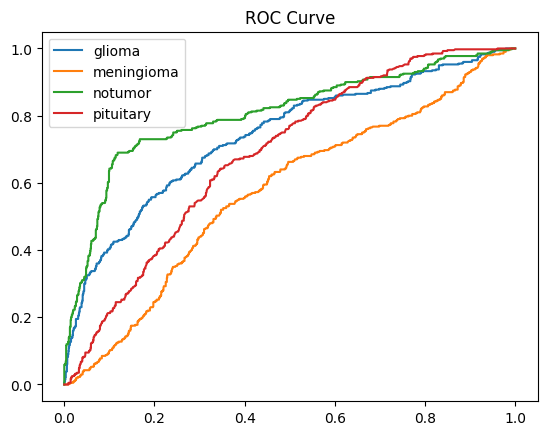

In [97]:
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure()

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(fpr, tpr, label=class_names[i])

plt.legend()
plt.title("ROC Curve")
plt.show()

In [100]:
cnn_loss, cnn_acc = cnn.evaluate(test_data)
print("CNN Test Accuracy:", cnn_acc)

vgg_loss, vgg_acc = vgg.evaluate(test_data)
print("VGG16 Test Accuracy:", vgg_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.6875 - loss: 1.0307
CNN Test Accuracy: 0.6875
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - accuracy: 0.2500 - loss: 1.3855
VGG16 Test Accuracy: 0.25


In [101]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "VGG16 (Transfer Learning)"],
    "Test Accuracy": [cnn_acc, vgg_acc],
    "Test Loss": [cnn_loss, vgg_loss]
})

print(results)

                       Model  Test Accuracy  Test Loss
0                        CNN         0.6875   1.030695
1  VGG16 (Transfer Learning)         0.2500   1.385494


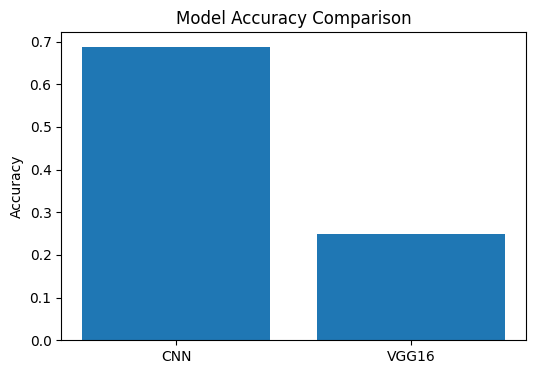

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(["CNN", "VGG16"], [cnn_acc, vgg_acc])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

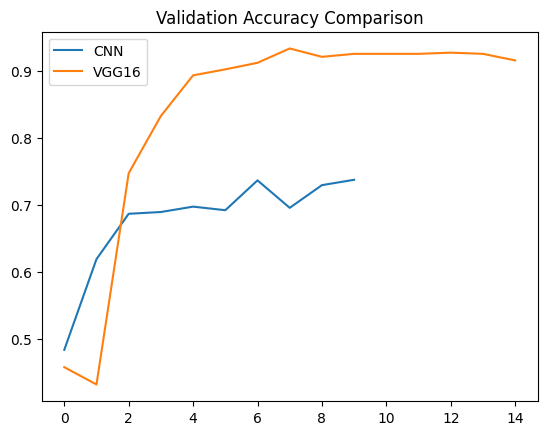

In [103]:
plt.plot(history_cnn.history['val_accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Validation Accuracy Comparison")
plt.legend(["CNN", "VGG16"])
plt.show()

In [104]:
import pandas as pd

cnn_loss, cnn_acc = cnn.evaluate(test_data)
vgg_loss, vgg_acc = vgg.evaluate(test_data)

comparison = pd.DataFrame({
    "Model": ["CNN", "VGG16 (Transfer Learning)"],
    "Loss": [cnn_loss, vgg_loss],
    "Accuracy": [cnn_acc, vgg_acc]
})

print(comparison)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6875 - loss: 1.0307
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.2500 - loss: 1.3855
                       Model      Loss  Accuracy
0                        CNN  1.030695    0.6875
1  VGG16 (Transfer Learning)  1.385494    0.2500


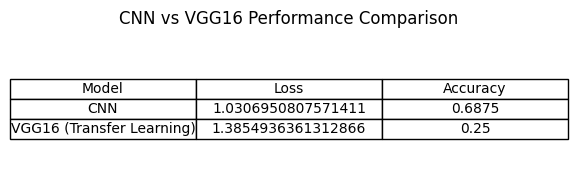

In [105]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("CNN vs VGG16 Performance Comparison")
plt.show()

In [106]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = vgg.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

target_names = list(test_data.class_indices.keys())

report = classification_report(y_true, y_pred_classes, target_names=target_names)

print(report)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.06      0.00      0.00       400
     notumor       0.25      1.00      0.40       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.25      1600
   macro avg       0.08      0.25      0.10      1600
weighted avg       0.08      0.25      0.10      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [107]:
plt.savefig("figure_name.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

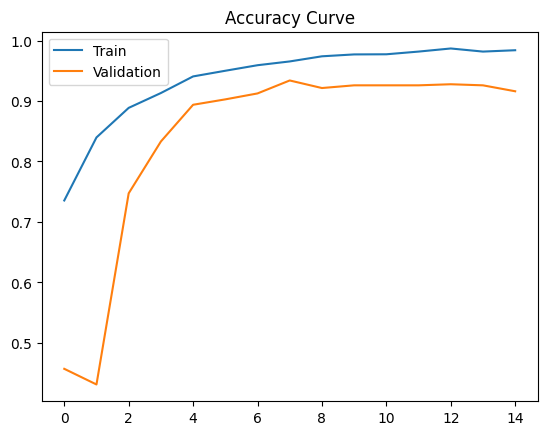

In [109]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(['Train','Validation'])

plt.savefig("accuracy_curve.png", dpi=300, bbox_inches='tight')
plt.show()

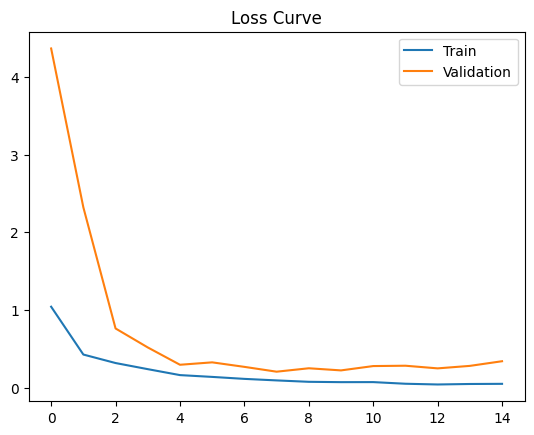

In [110]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(['Train','Validation'])

plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

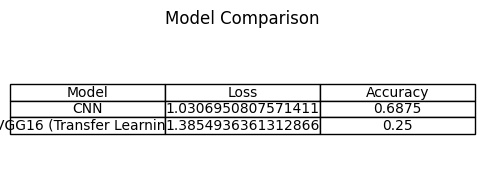

In [111]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Model Comparison")

plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()